In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abbas829/pakistan-human-development-indicators/hdro_indicators_pak.csv


# Import Libraries

In [2]:
!pip install -q xgboost lightgbm plotly

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#  LOAD DATA

In [3]:


path = "/kaggle/input/datasets/abbas829/pakistan-human-development-indicators/hdro_indicators_pak.csv"
df = pd.read_csv(path)

print("Original Shape:", df.shape)
display(df.head())


Original Shape: (971, 8)


,country_code,country_name,indicator_id,indicator_name,index_id,index_name,value,year
0,PAK,Pakistan,eys,Expected Years of Schooling (years),HDI,Human Development Index,4.238,1990
1,PAK,Pakistan,eys,Expected Years of Schooling (years),HDI,Human Development Index,4.281,1991
2,PAK,Pakistan,eys,Expected Years of Schooling (years),HDI,Human Development Index,4.323,1992
3,PAK,Pakistan,eys,Expected Years of Schooling (years),HDI,Human Development Index,4.365,1993
4,PAK,Pakistan,eys,Expected Years of Schooling (years),HDI,Human Development Index,4.408,1994


#  DATA CLEANING

In [4]:

df = df.drop_duplicates()

# remove constant columns
if df['country_name'].nunique() == 1:
    df = df.drop(['country_name'], axis=1)

if df['country_code'].nunique() == 1:
    df = df.drop(['country_code'], axis=1)

# convert year
df['year'] = df['year'].astype(int)

# missing
df = df.dropna()

print("Clean Shape:", df.shape)

Clean Shape: (971, 6)


#  FEATURE ENGINEERING

In [5]:
# encode categorical
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

df['indicator_id_enc'] = le1.fit_transform(df['indicator_id'])
df['indicator_name_enc'] = le2.fit_transform(df['indicator_name'])
df['index_id_enc'] = le3.fit_transform(df['index_id'])

# time features
df['year_squared'] = df['year'] ** 2
df['year_sin'] = np.sin(2*np.pi*df['year']/10)
df['year_cos'] = np.cos(2*np.pi*df['year']/10)

# lag features
df['lag1'] = df.groupby('indicator_id')['value'].shift(1)
df['lag2'] = df.groupby('indicator_id')['value'].shift(2)

# rolling features
df['rolling_mean3'] = df.groupby('indicator_id')['value'].transform(lambda x: x.rolling(3).mean())
df['rolling_std3'] = df.groupby('indicator_id')['value'].transform(lambda x: x.rolling(3).std())

df = df.dropna()

print("Feature Engineered Shape:", df.shape)

Feature Engineered Shape: (892, 16)


#  EDA

             value         year  indicator_id_enc  indicator_name_enc  \
count   892.000000   892.000000        892.000000          892.000000   
mean    487.156096  2008.172646         23.896861           28.587444   
std    1526.287109     9.310663         12.949809           13.076662   
min       0.280000  1992.000000          0.000000            0.000000   
25%       4.048500  2000.000000         14.000000           20.000000   
50%      27.598000  2009.000000         25.000000           30.000000   
75%      78.823500  2016.000000         36.000000           40.000000   
max    8967.022000  2023.000000         46.000000           47.000000   

       index_id_enc  year_squared      year_sin      year_cos         lag1  \
count    892.000000  8.920000e+02  8.920000e+02  8.920000e+02   892.000000   
mean       1.600897  4.032844e+06  6.610483e-02  1.548089e-14   479.354354   
std        1.918052  3.738591e+04  7.241091e-01  6.873235e-01  1502.750198   
min        0.000000  3.968064e

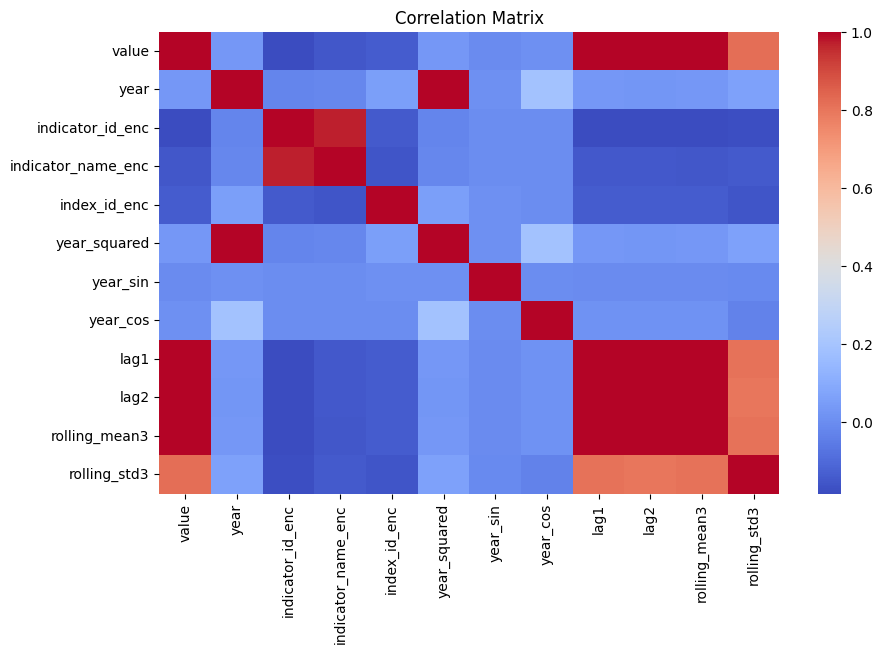

In [6]:
print(df.describe())

# correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


#  VISUALIZATION

In [7]:


fig1 = px.line(
    df,
    x="year",
    y="value",
    color="indicator_name",
    title="Human Development Indicators Trend"
)
fig1.show()

fig2 = px.box(
    df,
    x="index_name",
    y="value",
    title="Distribution of Development Index Values"
)
fig2.show()

fig3 = px.scatter(
    df,
    x="year",
    y="value",
    color="index_name",
    title="Year vs Indicator Value"
)
fig3.show()


#  ML DATASET

In [8]:
features = [
'year','year_squared','year_sin','year_cos',
'indicator_id_enc','indicator_name_enc','index_id_enc',
'lag1','lag2','rolling_mean3','rolling_std3'
]

X = df[features]
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#  MODELS

In [9]:

models = {

"RandomForest": RandomForestRegressor(n_estimators=200),

"XGBoost": XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
),

"LightGBM": LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    verbosity=-1
    
)

}

results = []

for name, model in models.items():
    
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    r2 = r2_score(y_test,preds)
    
    results.append([name,rmse,r2])

results_df = pd.DataFrame(results,columns=["Model","RMSE","R2"])
results_df = results_df.sort_values("R2",ascending=False)

print("\nModel Comparison")
display(results_df)



Model Comparison


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



,Model,RMSE,R2
0,RandomForest,30.108102,0.999141
1,XGBoost,56.360320,0.996990
2,LightGBM,94.066552,0.991615


#  MODEL COMPARISON VISUALIZATION

In [10]:
fig4 = px.bar(
    results_df,
    x="Model",
    y="R2",
    title="Model Performance Comparison"
)
fig4.show()


#  FEATURE IMPORTANCE 

In [11]:


best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

if hasattr(best_model,"feature_importances_"):
    
    imp = pd.DataFrame({
        "Feature":features,
        "Importance":best_model.feature_importances_
    }).sort_values("Importance",ascending=False)
    
    fig5 = px.bar(
        imp,
        x="Importance",
        y="Feature",
        orientation="h",
        title=f"{best_model_name} Feature Importance"
    )
    
    fig5.show()

print("\nPipeline Fahh")


Pipeline Fahh


# PROPHET TIME SERIES FORECASTING

13:39:19 - cmdstanpy - INFO - Chain [1] start processing
13:39:20 - cmdstanpy - INFO - Chain [1] done processing


Rows used for forecasting: 128


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



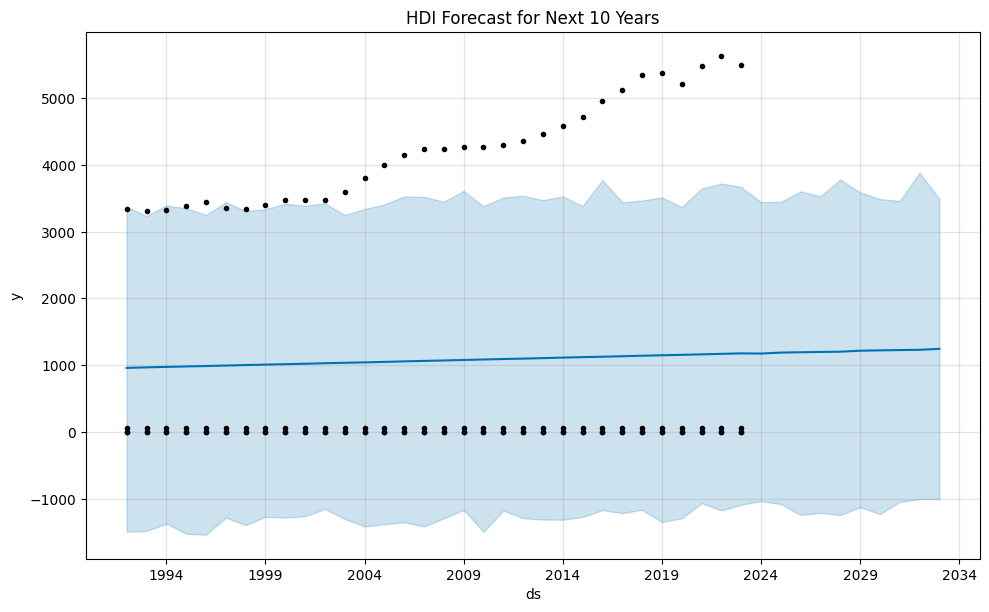

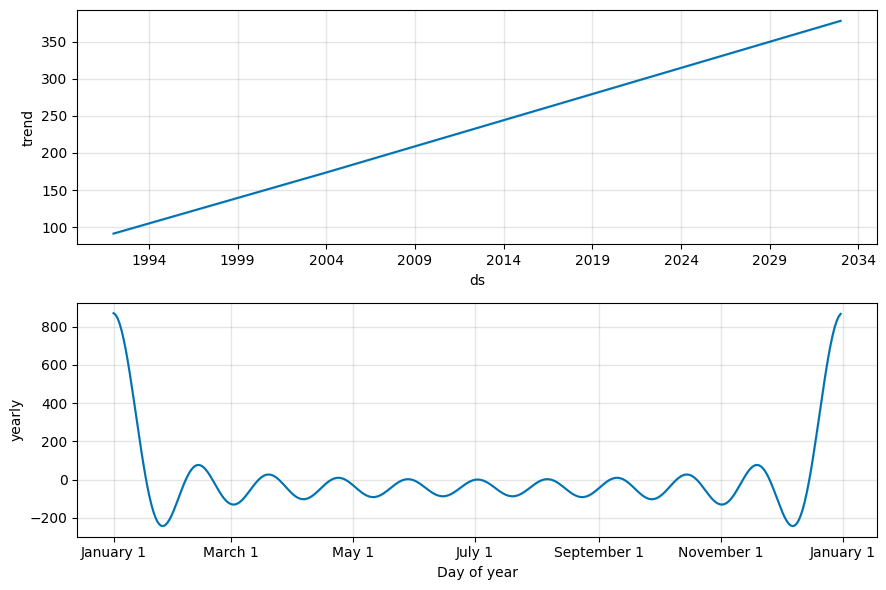

In [12]:


from prophet import Prophet

# select HDI index
ts = df[df['index_name'] == "Human Development Index"]

ts = ts[['year','value']].copy()

ts = ts.rename(columns={'year':'ds','value':'y'})

ts['ds'] = pd.to_datetime(ts['ds'], format='%Y')

print("Rows used for forecasting:", len(ts))

prophet_model = Prophet()

prophet_model.fit(ts)

future = prophet_model.make_future_dataframe(periods=10, freq='Y')

forecast = prophet_model.predict(future)

# Forecast plot
fig = prophet_model.plot(forecast)
plt.title("HDI Forecast for Next 10 Years")
plt.show()

# Components
prophet_model.plot_components(forecast)
plt.show()

# SHAP EXPLAINABILITY

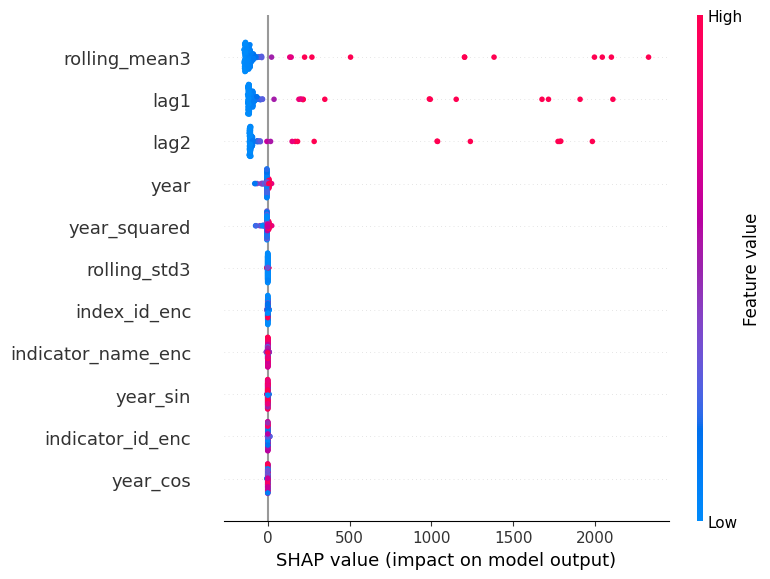

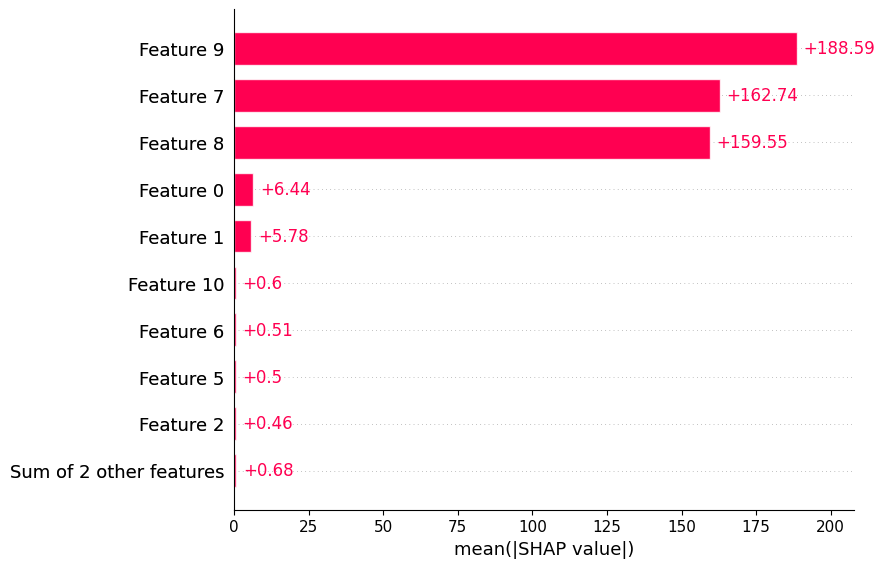

In [13]:
import shap

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

explainer = shap.Explainer(best_model, X_train)

shap_values = explainer(X_test, check_additivity=False)

# summary plot
shap.summary_plot(shap_values, X_test, feature_names=features)

# feature importance
shap.plots.bar(shap_values)